In [1]:
import torch
import numpy as np
import drone_2d_custom_gym_env.drone_2d_env
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_
import gym
from ppo import PPO
from utils import plot_learning_curve, Logger

pygame-ce 2.5.7 (SDL 2.32.10, Python 3.12.12)


objc[34946]: Class SDLApplication is implemented in both /Users/oli.dmrs/Documents/Personal Projects/COMP579_FinalProject/.venv/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1115a4a68) and /Users/oli.dmrs/Documents/Personal Projects/COMP579_FinalProject/.venv/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x13550c890). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[34946]: Class SDLAppDelegate is implemented in both /Users/oli.dmrs/Documents/Personal Projects/COMP579_FinalProject/.venv/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1115a4ab8) and /Users/oli.dmrs/Documents/Personal Projects/COMP579_FinalProject/.venv/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x13550c8e0). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[34946]: Class SDLTranslatorResponder is implemented

In [2]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
CASE_ID = 1

CASES = {
    1: {"initial_throw": True, "initial_force": 5000, "initial_rotation_force": 600,"wind":None,"wind_magnitude":100},
    2: {"initial_throw": True, "initial_force": 12000, "initial_rotation_force": 1500,"wind":None,"wind_magnitude":100},
    3: {"initial_throw": True, "initial_force": 5000, "initial_rotation_force": 600,"wind": "Uniform","wind_magnitude":100},
    4: {"initial_throw": True, "initial_force": 12000, "initial_rotation_force": 1500,"wind": "Uniform","wind_magnitude":100},
    5: {"initial_throw": True, "initial_force": 5000, "initial_rotation_force": 600,"wind": "Random","wind_magnitude":100},
    6: {"initial_throw": True, "initial_force": 12000, "initial_rotation_force": 1500,"wind": "Random","wind_magnitude":100}
}

def make_env(case_id, render_sim = False):
    case = CASES[case_id]
    return gym.make(
        "drone-2d-custom-v0",
        render_sim=render_sim,
        render_path=True,
        render_shade=True,
        shade_distance = 75,
        n_steps = 500,
        n_fall_steps = 5,
        change_target=False,
        initial_throw=case["initial_throw"],
        initial_force=case["initial_force"],
        initial_rotation_force=case["initial_rotation_force"],
        step_penalty = 0.1,
        goal_reward = 10.0,
        death_penalty = 0.0,
        success_radius = 25.0
    )

NB_EPISODES = 1000
EVAL_EP_FREQ = 50

training_env = make_env(CASE_ID)
eval_env = make_env(CASE_ID)

ppo_agent = PPO(
    training_env = training_env,
    eval_env = eval_env,
    policy_neurons_size = [128, 128],
    value_neurons_size = [128, 128],
    lr_policy = 1e-4,
    lr_value = 1e-4,
    gamma = 0.99,
    lamda = 0.95,
    time_steps_per_batch = 2048,
    epochs = 5,
    epsilon = 0.2,
    mini_batch_size = 64,
    nb_eval_episodes = 200,
    logger = Logger.PPO(CASE_ID),
)

eval_mean_returns = []
eval_std_returns = []
current_best = -np.inf

for ep in range(NB_EPISODES):
    
    ppo_agent.learn()
    
    if ep % EVAL_EP_FREQ == 0:
        avg_return, std_return = ppo_agent.evaluation_phase()
        eval_mean_returns.append(avg_return)
        eval_std_returns.append(std_return)

        if avg_return > current_best:
            current_best = avg_return

        print(f'ep: {ep}, avg eval return {round(avg_return, 2)}, best avg eval return: {round(current_best, 2)}')

ppo_agent.logger.log_training_metrics()

/Users/oli.dmrs/Documents/Personal Projects/COMP579_FinalProject/.venv/lib/python3.12/site-packages/gym/utils/passive_env_checker.py:174: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.warn(
/Users/oli.dmrs/Documents/Personal Projects/COMP579_FinalProject/.venv/lib/python3.12/site-packages/gym/utils/passive_env_checker.py:187: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.warn(
/Users/oli.dmrs/Documents/Personal Projects/COMP579_FinalProject/.venv/lib/python3.12/site-packages/gym/utils/passive_env_checker.py:195: UserWarning: WARN: The result returned by `env.reset()` was not a tuple of the form `(obs, info)`, where `obs` is a observation and `info` is a dictionary containing additional information. Actual type: `<class 

ep: 0, avg eval return -9.29, best avg eval return: -9.29
ep: 50, avg eval return -4.85, best avg eval return: -4.85
ep: 100, avg eval return -4.39, best avg eval return: -4.39
ep: 150, avg eval return -4.29, best avg eval return: -4.29
ep: 200, avg eval return -4.18, best avg eval return: -4.18
ep: 250, avg eval return -4.11, best avg eval return: -4.11
ep: 300, avg eval return -4.45, best avg eval return: -4.11
ep: 350, avg eval return -3.9, best avg eval return: -3.9
ep: 400, avg eval return -3.99, best avg eval return: -3.9
ep: 450, avg eval return -4.0, best avg eval return: -3.9
ep: 500, avg eval return -4.2, best avg eval return: -3.9
ep: 550, avg eval return -4.33, best avg eval return: -3.9
ep: 600, avg eval return -3.93, best avg eval return: -3.9
ep: 650, avg eval return -3.94, best avg eval return: -3.9
ep: 700, avg eval return -4.14, best avg eval return: -3.9
ep: 750, avg eval return -3.95, best avg eval return: -3.9
ep: 800, avg eval return -4.19, best avg eval return: -

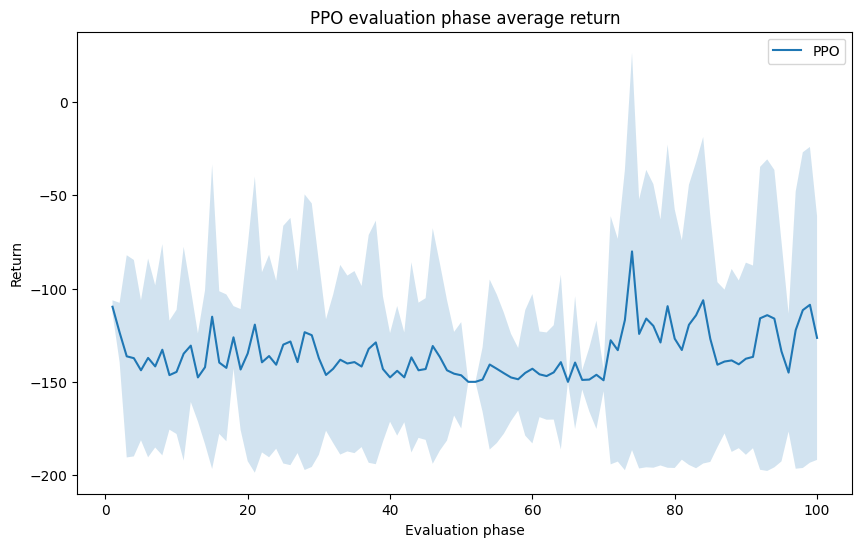

In [3]:
plot_learning_curve(
    x = np.arange(1, len(eval_mean_returns) + 1),
    y = np.array(eval_mean_returns),
    title = 'PPO evaluation phase average return',
    xlabel = 'Evaluation phase',
    ylabel = 'Return',
    std_values = np.array(eval_std_returns),
    legend_labels = ['PPO']
)